In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the Iris dataset
from sklearn.datasets import load_iris

# Load data
iris = load_iris()
print("Dataset loaded successfully!\n")

# Create a DataFrame for easier manipulation
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Display basic information
print("=== DATASET INFORMATION ===")
print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nLast 5 rows:")
print(df.tail())
print("\n" + "="*50)

# Dataset description
print("\n=== DATASET DESCRIPTION ===")
print(df.describe())
print("\n" + "="*50)

# Check for missing values
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n" + "="*50)

# Check class distribution
print("\n=== CLASS DISTRIBUTION ===")
print(df['species'].value_counts())
print("\n" + "="*50)

Dataset loaded successfully!

=== DATASET INFORMATION ===
Dataset Shape: (150, 5)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Last 5 rows:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148               

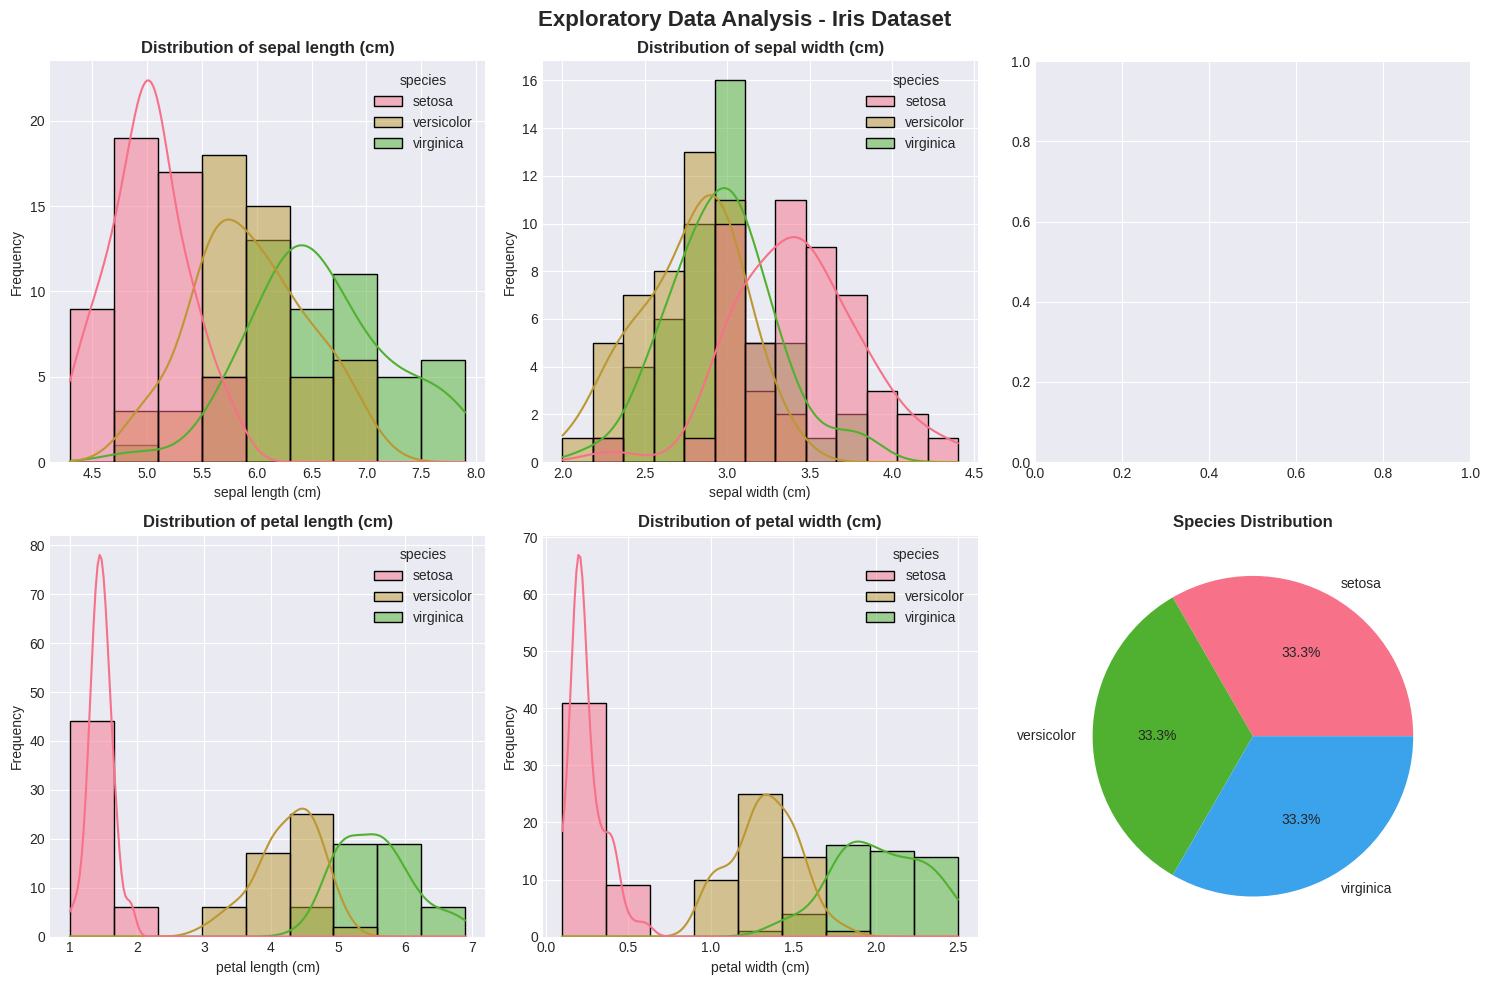


Generating pairplot...


<Figure size 1200x800 with 0 Axes>

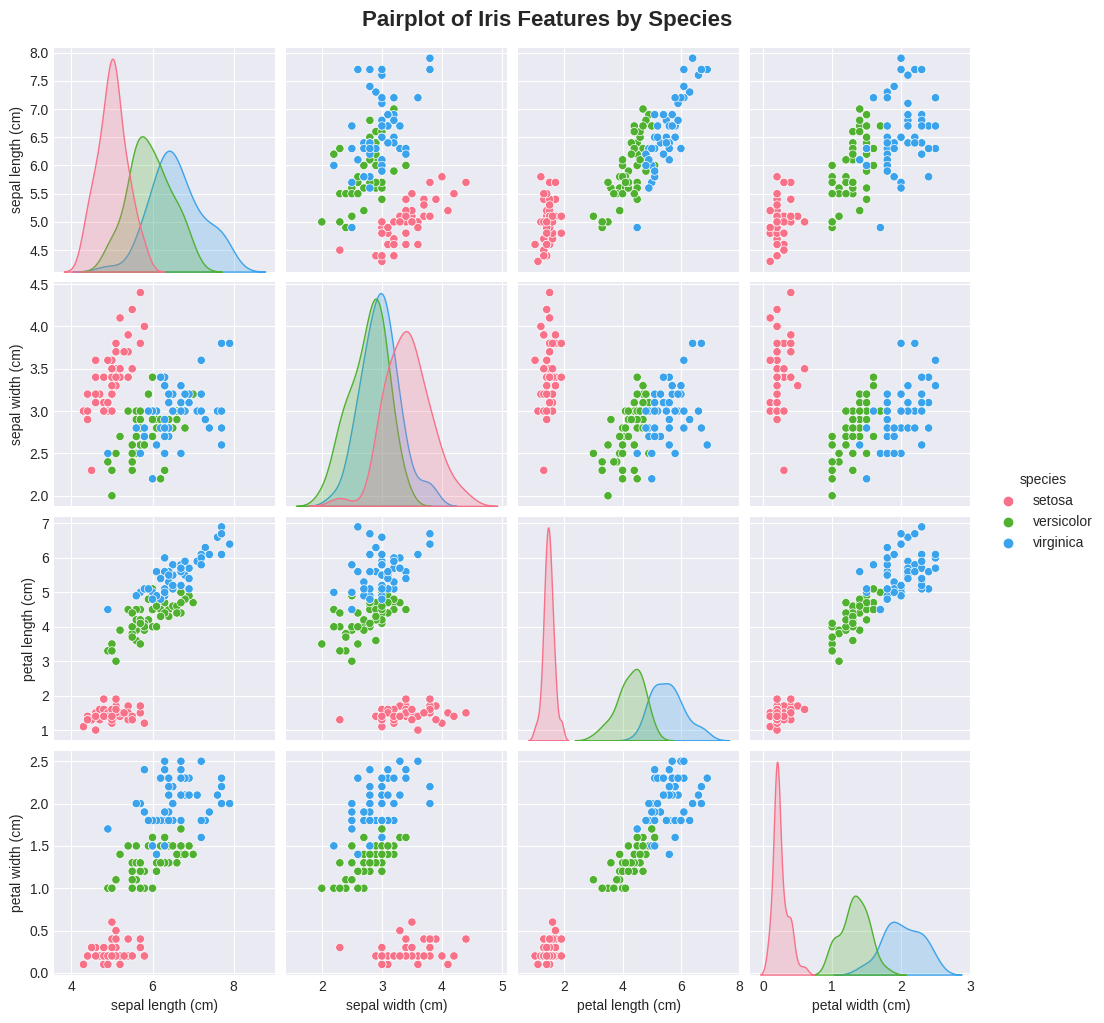

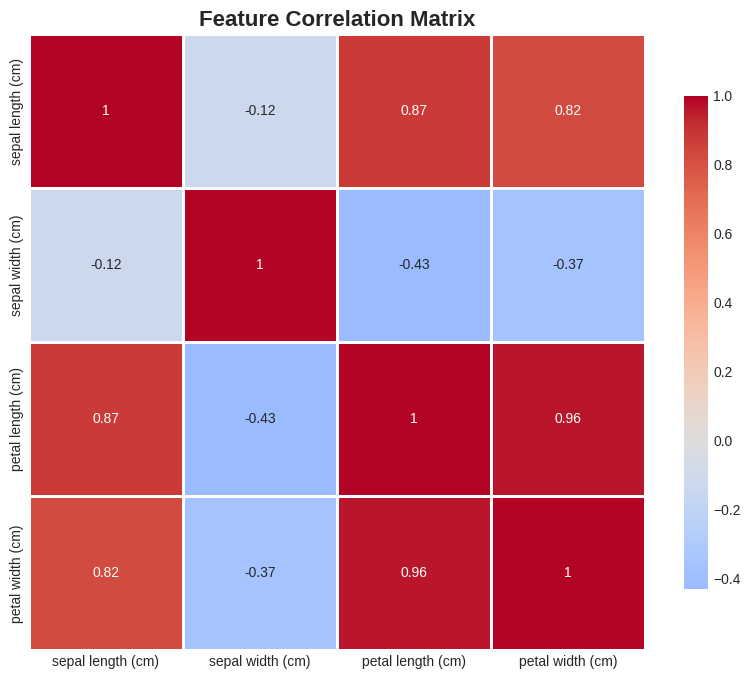

In [3]:
# Visualize the dataset
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Exploratory Data Analysis - Iris Dataset', fontsize=16, fontweight='bold')

# Feature distributions
features = iris.feature_names
for i, feature in enumerate(features):
    row, col = divmod(i, 2)
    sns.histplot(data=df, x=feature, hue='species', kde=True, ax=axes[row, col])
    axes[row, col].set_title(f'Distribution of {feature}', fontweight='bold')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')

# Class distribution pie chart
species_counts = df['species'].value_counts()
axes[1, 2].pie(species_counts.values, labels=species_counts.index, autopct='%1.1f%%', 
               colors=sns.color_palette("husl", 3))
axes[1, 2].set_title('Species Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

# Pairplot for feature relationships
print("\nGenerating pairplot...")
plt.figure(figsize=(12, 8))
sns.pairplot(df, hue='species', palette='husl', diag_kind='kde')
plt.suptitle('Pairplot of Iris Features by Species', y=1.02, fontsize=16, fontweight='bold')
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df.drop('species', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.show()

In [4]:
print("=== DATA PREPROCESSING ===\n")

# Separate features and target
X = df.drop('species', axis=1)
y = df['species']

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Target classes mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{i}: {class_name}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully!")
print("="*50)

=== DATA PREPROCESSING ===

Target classes mapping:
0: setosa
1: versicolor
2: virginica

Training set size: (120, 4)
Testing set size: (30, 4)

Features scaled successfully!


In [5]:
print("=== MODEL TRAINING WITH MULTIPLE ALGORITHMS ===\n")

# Define a list of models to evaluate
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=200),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Gaussian Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Dictionary to store model results
results = {}
best_model = None
best_accuracy = 0

# Train and evaluate each model
for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {model_name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    
    print(f"{model_name} Accuracy: {accuracy:.4f}")
    
    # Track the best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model_name

print(f"\n{'='*60}")
print(f"✓ Best Model: {best_model} with accuracy: {best_accuracy:.4f}")
print("="*60)

=== MODEL TRAINING WITH MULTIPLE ALGORITHMS ===


Training Logistic Regression...
Logistic Regression Accuracy: 0.9333

Training Decision Tree...
Decision Tree Accuracy: 0.9333

Training Random Forest...
Random Forest Accuracy: 0.9000

Training SVM...
SVM Accuracy: 0.9667

Training K-Nearest Neighbors...
K-Nearest Neighbors Accuracy: 0.9333

Training Gaussian Naive Bayes...
Gaussian Naive Bayes Accuracy: 0.9667

Training Gradient Boosting...
Gradient Boosting Accuracy: 0.9667

✓ Best Model: SVM with accuracy: 0.9667


=== MODEL EVALUATION AND COMPARISON ===

Model Performance Comparison:
               Model  Accuracy
   Gradient Boosting  0.966667
Gaussian Naive Bayes  0.966667
                 SVM  0.966667
 Logistic Regression  0.933333
       Decision Tree  0.933333
 K-Nearest Neighbors  0.933333
       Random Forest  0.900000


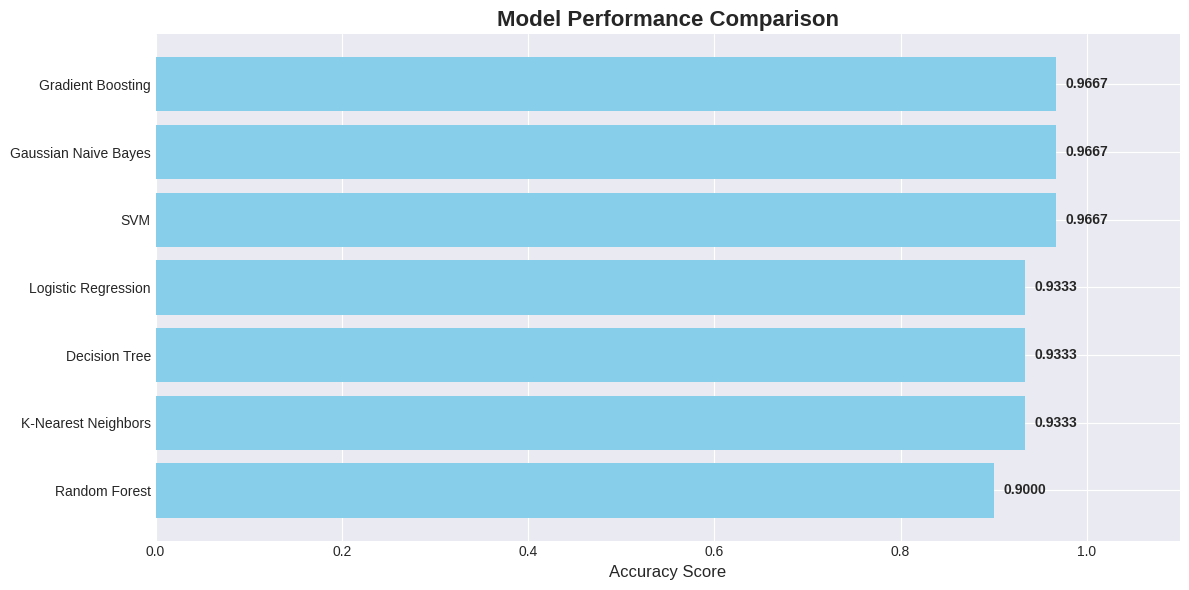


DETAILED EVALUATION FOR BEST MODEL: SVM

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



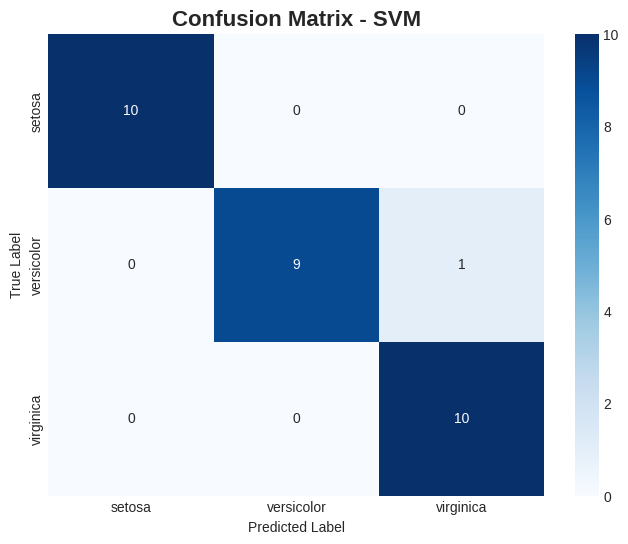


Cross-Validation Scores (5-fold):
Cross-validation scores: [0.91666667 1.         0.95833333 0.95833333 1.        ]
Mean CV accuracy: 0.9667 (+/- 0.0624)


In [6]:
print("=== MODEL EVALUATION AND COMPARISON ===\n")

# Create a comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[model]['accuracy'] for model in results.keys()]
}).sort_values('Accuracy', ascending=False)

print("Model Performance Comparison:")
print(comparison_df.to_string(index=False))

# Visualize model comparison
plt.figure(figsize=(12, 6))
bars = plt.barh(comparison_df['Model'], comparison_df['Accuracy'], color='skyblue')
plt.xlabel('Accuracy Score', fontsize=12)
plt.title('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.xlim(0, 1.1)

# Add accuracy values on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='left', va='center', fontweight='bold')

plt.gca().invert_yaxis()  # Highest accuracy on top
plt.tight_layout()
plt.show()

# Display detailed evaluation for the best model
print(f"\n{'='*60}")
print(f"DETAILED EVALUATION FOR BEST MODEL: {best_model}")
print("="*60)

best_model_result = results[best_model]
y_pred_best = best_model_result['predictions']

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, 
                           target_names=label_encoder.classes_))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model}', fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Cross-validation for the best model
print("\nCross-Validation Scores (5-fold):")
cv_scores = cross_val_score(results[best_model]['model'], X_train_scaled, y_train, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

=== FEATURE IMPORTANCE ANALYSIS ===

SVM doesn't provide direct feature importance metrics.

Using alternative methods for feature importance analysis...
------------------------------------------------------------

Calculating Permutation Importance...

Permutation Importance Results:
          Feature  Importance      Std
 petal width (cm)    0.296667 0.073711
petal length (cm)    0.240000 0.046667
 sepal width (cm)    0.063333 0.027689
sepal length (cm)    0.006667 0.013333


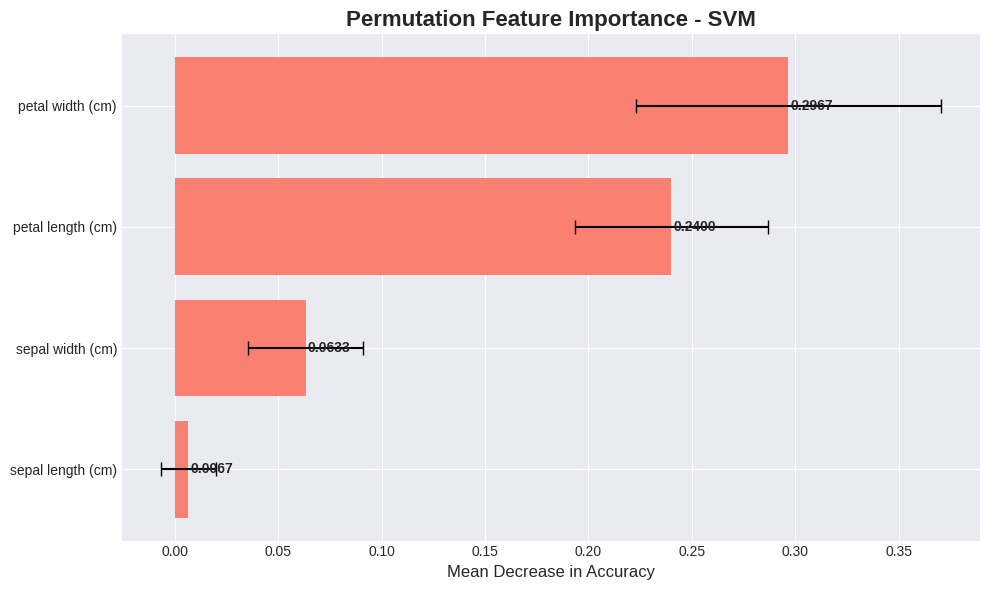


Alternative: Using Random Forest as a surrogate model for feature importance

Random Forest Surrogate Feature Importance:
          Feature  Importance
 petal width (cm)    0.437185
petal length (cm)    0.431466
sepal length (cm)    0.116349
 sepal width (cm)    0.015000


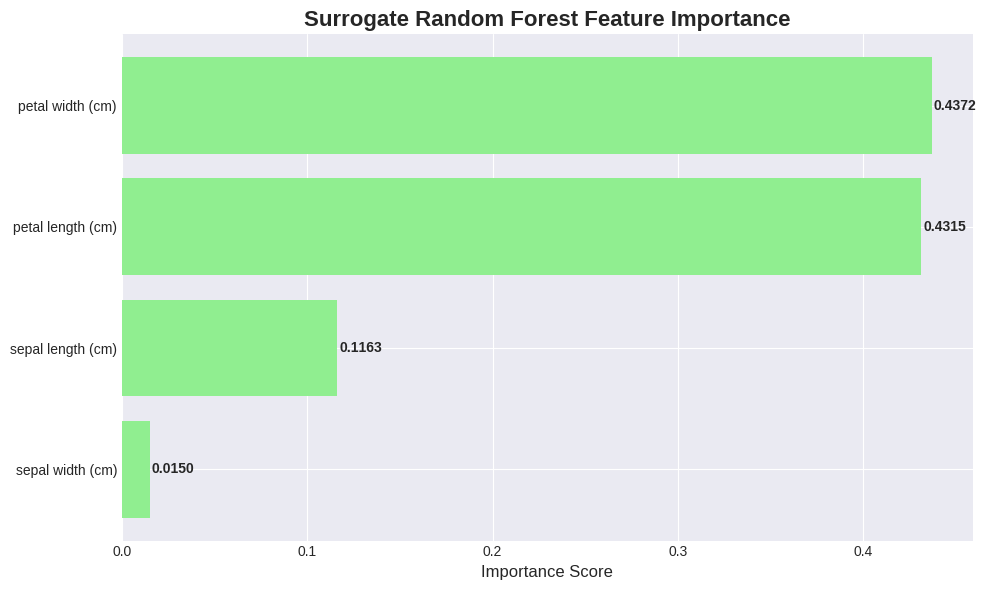


Alternative: Correlation Analysis with Target Variable

Absolute Correlation with Target Variable:
          Feature  Abs_Correlation_with_Target
 petal width (cm)                     0.956547
petal length (cm)                     0.949035
sepal length (cm)                     0.782561
 sepal width (cm)                     0.426658


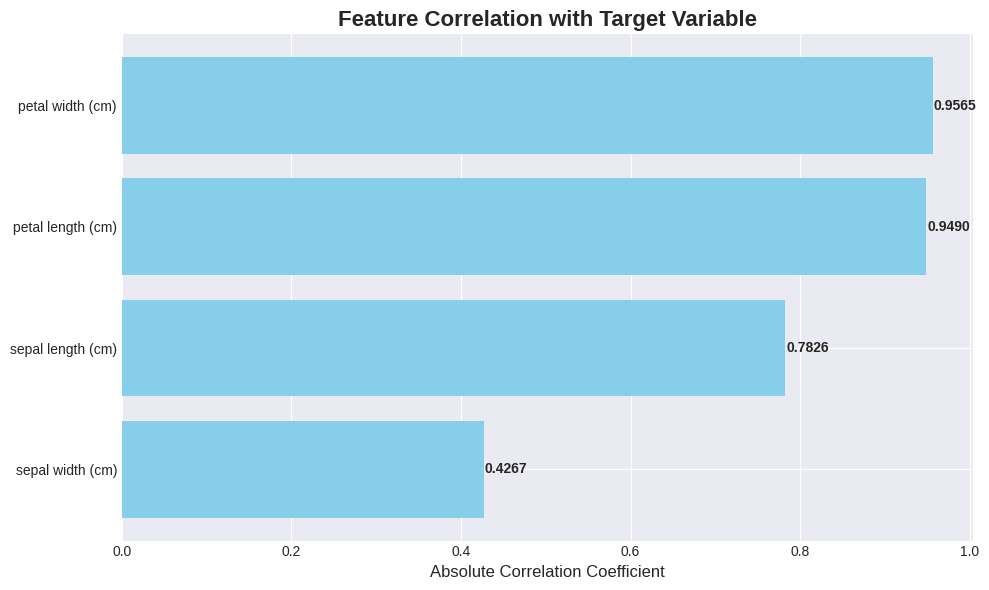


SUMMARY OF FEATURE IMPORTANCE ANALYSIS

Feature Ranking Summary (1 = Most Important):
          Feature  Avg_Rank  Perm_Rank  RF_Rank  Corr_Rank
 petal width (cm)  1.000000          1        1          1
petal length (cm)  2.000000          2        2          2
sepal length (cm)  3.333333          4        3          3
 sepal width (cm)  3.666667          3        4          4


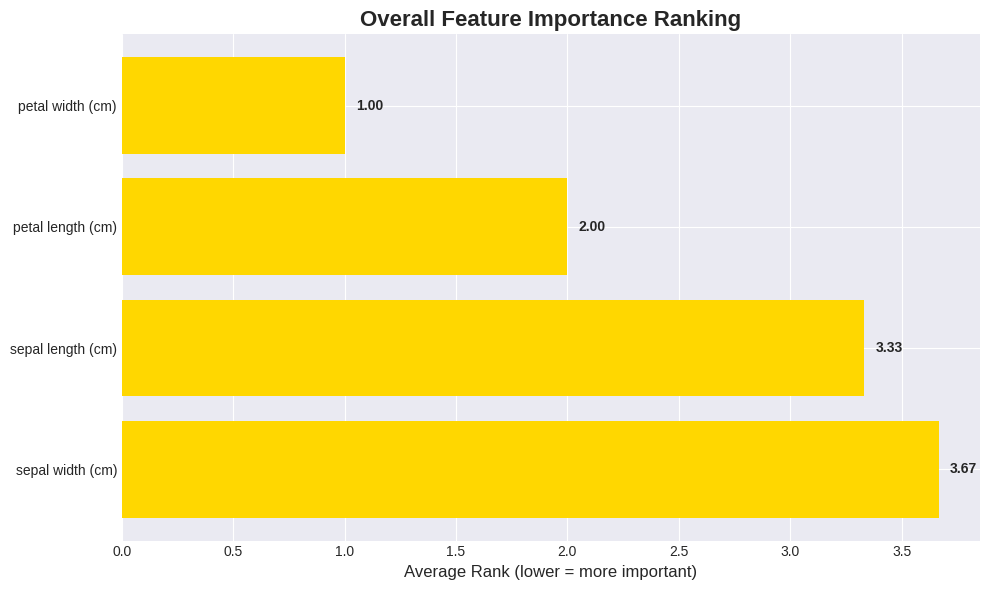

In [8]:
print("=== FEATURE IMPORTANCE ANALYSIS ===\n")

# Method 1: Check if the best model has feature_importance attribute
if hasattr(results[best_model]['model'], 'feature_importances_'):
    feature_importance = results[best_model]['model'].feature_importances_
    
    # Create a DataFrame for feature importance
    feature_importance_df = pd.DataFrame({
        'Feature': iris.feature_names,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)
    
    print("Feature Importance (from model):")
    print(feature_importance_df.to_string(index=False))
    
    # Visualize feature importance
    plt.figure(figsize=(10, 6))
    bars = plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='lightgreen')
    plt.xlabel('Importance Score', fontsize=12)
    plt.title(f'Feature Importance - {best_model}', fontsize=16, fontweight='bold')
    
    # Add values on bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                 f'{width:.4f}', ha='left', va='center', fontweight='bold')
    
    plt.gca().invert_yaxis()  # Highest importance on top
    plt.tight_layout()
    plt.show()
    
elif hasattr(results[best_model]['model'], 'coef_'):
    # For linear models with coefficients
    coefficients = results[best_model]['model'].coef_
    
    if len(coefficients.shape) > 1:  # For multi-class
        # Take average absolute coefficient across all classes
        coefficients = np.mean(np.abs(coefficients), axis=0)
    else:
        coefficients = np.abs(coefficients)
    
    # Create a DataFrame for coefficients
    coeff_df = pd.DataFrame({
        'Feature': iris.feature_names,
        'Coefficient': coefficients
    }).sort_values('Coefficient', ascending=False)
    
    print("Feature Coefficients (absolute values):")
    print(coeff_df.to_string(index=False))
    
    # Visualize coefficients
    plt.figure(figsize=(10, 6))
    bars = plt.barh(coeff_df['Feature'], coeff_df['Coefficient'], color='lightblue')
    plt.xlabel('Coefficient Value', fontsize=12)
    plt.title(f'Feature Coefficients - {best_model}', fontsize=16, fontweight='bold')
    
    # Add values on bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                 f'{width:.4f}', ha='left', va='center', fontweight='bold')
    
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

else:
    print(f"{best_model} doesn't provide direct feature importance metrics.")
    print("\nUsing alternative methods for feature importance analysis...")
    print("-" * 60)
    
    # Method 2: Use permutation importance (works for any model)
    from sklearn.inspection import permutation_importance
    
    print("\nCalculating Permutation Importance...")
    
    # Calculate permutation importance
    perm_importance = permutation_importance(
        results[best_model]['model'], 
        X_test_scaled, 
        y_test, 
        n_repeats=10,
        random_state=42
    )
    
    # Create a DataFrame for permutation importance
    perm_importance_df = pd.DataFrame({
        'Feature': iris.feature_names,
        'Importance': perm_importance.importances_mean,
        'Std': perm_importance.importances_std
    }).sort_values('Importance', ascending=False)
    
    print("\nPermutation Importance Results:")
    print(perm_importance_df.to_string(index=False))
    
    # Visualize permutation importance
    plt.figure(figsize=(10, 6))
    x_pos = np.arange(len(perm_importance_df['Feature']))
    
    bars = plt.barh(perm_importance_df['Feature'], perm_importance_df['Importance'], 
                    color='salmon', xerr=perm_importance_df['Std'], capsize=5)
    plt.xlabel('Mean Decrease in Accuracy', fontsize=12)
    plt.title(f'Permutation Feature Importance - {best_model}', fontsize=16, fontweight='bold')
    
    # Add values on bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                 f'{width:.4f}', ha='left', va='center', fontweight='bold')
    
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Method 3: Use Random Forest as a surrogate model to estimate feature importance
    print("\n" + "="*60)
    print("Alternative: Using Random Forest as a surrogate model for feature importance")
    print("="*60)
    
    # Train a Random Forest to get feature importance
    rf_surrogate = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_surrogate.fit(X_train_scaled, y_train)
    
    # Get feature importance
    rf_importance = rf_surrogate.feature_importances_
    
    # Create a DataFrame
    rf_importance_df = pd.DataFrame({
        'Feature': iris.feature_names,
        'Importance': rf_importance
    }).sort_values('Importance', ascending=False)
    
    print("\nRandom Forest Surrogate Feature Importance:")
    print(rf_importance_df.to_string(index=False))
    
    # Visualize
    plt.figure(figsize=(10, 6))
    bars = plt.barh(rf_importance_df['Feature'], rf_importance_df['Importance'], color='lightgreen')
    plt.xlabel('Importance Score', fontsize=12)
    plt.title('Surrogate Random Forest Feature Importance', fontsize=16, fontweight='bold')
    
    # Add values on bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                 f'{width:.4f}', ha='left', va='center', fontweight='bold')
    
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Method 4: Correlation with target (simple but effective)
    print("\n" + "="*60)
    print("Alternative: Correlation Analysis with Target Variable")
    print("="*60)
    
    # Calculate correlation between features and encoded target
    correlation_with_target = []
    for i, feature in enumerate(iris.feature_names):
        correlation = np.corrcoef(df[feature], y_encoded)[0, 1]
        correlation_with_target.append(abs(correlation))  # Use absolute value
    
    # Create a DataFrame
    correlation_df = pd.DataFrame({
        'Feature': iris.feature_names,
        'Abs_Correlation_with_Target': correlation_with_target
    }).sort_values('Abs_Correlation_with_Target', ascending=False)
    
    print("\nAbsolute Correlation with Target Variable:")
    print(correlation_df.to_string(index=False))
    
    # Visualize
    plt.figure(figsize=(10, 6))
    bars = plt.barh(correlation_df['Feature'], correlation_df['Abs_Correlation_with_Target'], color='skyblue')
    plt.xlabel('Absolute Correlation Coefficient', fontsize=12)
    plt.title('Feature Correlation with Target Variable', fontsize=16, fontweight='bold')
    
    # Add values on bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                 f'{width:.4f}', ha='left', va='center', fontweight='bold')
    
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Summary of all methods
    print("\n" + "="*60)
    print("SUMMARY OF FEATURE IMPORTANCE ANALYSIS")
    print("="*60)
    
    # Combine all importance scores
    feature_scores = {}
    for feature in iris.feature_names:
        feature_scores[feature] = {
            'Permutation_Importance': perm_importance_df[perm_importance_df['Feature'] == feature]['Importance'].values[0],
            'RF_Surrogate': rf_importance_df[rf_importance_df['Feature'] == feature]['Importance'].values[0],
            'Correlation': correlation_df[correlation_df['Feature'] == feature]['Abs_Correlation_with_Target'].values[0]
        }
    
    # Calculate average rank
    rank_data = []
    for feature in iris.feature_names:
        scores = feature_scores[feature]
        # Get ranks (1 = most important)
        perm_rank = list(perm_importance_df['Feature']).index(feature) + 1
        rf_rank = list(rf_importance_df['Feature']).index(feature) + 1
        corr_rank = list(correlation_df['Feature']).index(feature) + 1
        
        avg_rank = (perm_rank + rf_rank + corr_rank) / 3
        
        rank_data.append({
            'Feature': feature,
            'Avg_Rank': avg_rank,
            'Perm_Rank': perm_rank,
            'RF_Rank': rf_rank,
            'Corr_Rank': corr_rank
        })
    
    rank_df = pd.DataFrame(rank_data).sort_values('Avg_Rank')
    
    print("\nFeature Ranking Summary (1 = Most Important):")
    print(rank_df.to_string(index=False))
    
    # Visualize final ranking
    plt.figure(figsize=(10, 6))
    features_sorted = rank_df['Feature'].tolist()
    avg_ranks = rank_df['Avg_Rank'].tolist()
    
    bars = plt.barh(features_sorted, avg_ranks, color='gold')
    plt.xlabel('Average Rank (lower = more important)', fontsize=12)
    plt.title('Overall Feature Importance Ranking', fontsize=16, fontweight='bold')
    
    # Add values on bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.05, bar.get_y() + bar.get_height()/2, 
                 f'{width:.2f}', ha='left', va='center', fontweight='bold')
    
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [9]:
print("=== MAKING PREDICTIONS ON NEW DATA ===\n")

# Create some sample data for prediction
sample_data = [
    [5.1, 3.5, 1.4, 0.2],  # Setosa-like
    [6.0, 2.9, 4.5, 1.5],  # Versicolor-like
    [7.2, 3.0, 5.8, 2.1],  # Virginica-like
    [5.8, 2.7, 5.1, 1.9],  # Mixed features
]

sample_df = pd.DataFrame(sample_data, columns=iris.feature_names)
print("Sample data for prediction:")
print(sample_df)

# Scale the sample data
sample_scaled = scaler.transform(sample_df)

# Make predictions using the best model
predictions = results[best_model]['model'].predict(sample_scaled)
predicted_species = label_encoder.inverse_transform(predictions)

# Add predictions to the sample dataframe
sample_df['Predicted Species'] = predicted_species
sample_df['Predicted Code'] = predictions

print("\nPredictions:")
print(sample_df)

# Display prediction probabilities (if available)
if hasattr(results[best_model]['model'], 'predict_proba'):
    probabilities = results[best_model]['model'].predict_proba(sample_scaled)
    prob_df = pd.DataFrame(probabilities, columns=label_encoder.classes_)
    print("\nPrediction Probabilities:")
    print(prob_df)

=== MAKING PREDICTIONS ON NEW DATA ===

Sample data for prediction:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                6.0               2.9                4.5               1.5
2                7.2               3.0                5.8               2.1
3                5.8               2.7                5.1               1.9

Predictions:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                6.0               2.9                4.5               1.5   
2                7.2               3.0                5.8               2.1   
3                5.8               2.7                5.1               1.9   

  Predicted Species  Predicted Code  
0            setosa               0  
1        versicolor               1  
2         virginica         

In [11]:
print("=== SAVING MODEL AND RESULTS ===\n")

import joblib
import json
from datetime import datetime

# Create a timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save the best model
model_filename = f'iris_classification_model_{timestamp}.pkl'
joblib.dump(results[best_model]['model'], model_filename)
print(f"✓ Model saved as: {model_filename}")

# Save the scaler
scaler_filename = f'scaler_{timestamp}.pkl'
joblib.dump(scaler, scaler_filename)
print(f"✓ Scaler saved as: {scaler_filename}")

# Save the label encoder
encoder_filename = f'label_encoder_{timestamp}.pkl'
joblib.dump(label_encoder, encoder_filename)
print(f"✓ Label encoder saved as: {encoder_filename}")

# Save results summary
results_summary = {
    'best_model': best_model,
    'best_accuracy': float(best_accuracy),
    'all_models_accuracy': {model: float(results[model]['accuracy']) for model in results},
    'timestamp': timestamp,
    'features': list(iris.feature_names),  # FIXED: Use list() instead of .tolist()
    'classes': label_encoder.classes_.tolist()  # This is fine, it's a numpy array
}

results_filename = f'results_summary_{timestamp}.json'
with open(results_filename, 'w') as f:
    json.dump(results_summary, f, indent=4)

print(f"✓ Results summary saved as: {results_filename}")

# Create a simple report
report = f"""
IRIS FLOWER CLASSIFICATION - MODEL TRAINING REPORT
{'='*50}
Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

Dataset Information:
- Total samples: {len(df)}
- Features: {', '.join(iris.feature_names)}
- Classes: {', '.join(label_encoder.classes_)}

Data Split:
- Training samples: {X_train.shape[0]}
- Testing samples: {X_test.shape[0]}

Model Performance:
- Best Model: {best_model}
- Test Accuracy: {best_accuracy:.4f}

All Models Performance:
{comparison_df.to_string(index=False)}

Files Created:
1. {model_filename} - Trained model
2. {scaler_filename} - Feature scaler
3. {encoder_filename} - Label encoder
4. {results_filename} - Results summary

Model is ready for deployment!
"""

print(report)

=== SAVING MODEL AND RESULTS ===

✓ Model saved as: iris_classification_model_20251228_161424.pkl
✓ Scaler saved as: scaler_20251228_161424.pkl
✓ Label encoder saved as: label_encoder_20251228_161424.pkl
✓ Results summary saved as: results_summary_20251228_161424.json

IRIS FLOWER CLASSIFICATION - MODEL TRAINING REPORT
Date: 2025-12-28 16:14:24

Dataset Information:
- Total samples: 150
- Features: sepal length (cm), sepal width (cm), petal length (cm), petal width (cm)
- Classes: setosa, versicolor, virginica

Data Split:
- Training samples: 120
- Testing samples: 30

Model Performance:
- Best Model: SVM
- Test Accuracy: 0.9667

All Models Performance:
               Model  Accuracy
   Gradient Boosting  0.966667
Gaussian Naive Bayes  0.966667
                 SVM  0.966667
 Logistic Regression  0.933333
       Decision Tree  0.933333
 K-Nearest Neighbors  0.933333
       Random Forest  0.900000

Files Created:
1. iris_classification_model_20251228_161424.pkl - Trained model
2. scaler